<div align="center">

<h1> <b> THERMALLY ACTIVATED SURFACE RELAXATION WITH ANGULAR INCIDENCE </b> </h1>

</div>

<br>

<hr size=10 noshade color="green">
<p>
<p><img alt="UdeA logo" height="180px" src="https://upload.wikimedia.org/wikipedia/commons/archive/f/fb/20161010213812%21Escudo-UdeA.svg" align="left" hspace="100px" vspace="4px"></p>

<div align="right">       

<h3><i> <b>Cristian Vergara <br>
Juan Palacio <br>
Sofía Moscoso <br>
Lucas Perdomo</b> <br>  
Universidad de Antioquia <br>
Instituto de Física  <br>
</i></h3>
</div>

---

## 1. Introducción y Objetivos

En las etapas previas de este proyecto incremental, asumimos una aproximación idealizada donde el flujo de partículas de cobre incidía de manera estrictamente ortogonal (perpendicular) sobre el sustrato de vidrio. Sin embargo, en una cámara de evaporación térmica real, la fuente de evaporación (crisol o filamento) actúa como una fuente puntual o extendida desde la cual los átomos emergen con una distribución de direcciones espaciales. 

Este cuarto notebook incorpora el fenómeno de la **Incidencia Angular de las Partículas**. Analizaremos cómo pequeñas desviaciones estocásticas respecto a la normal del sustrato modifican los patrones de deposición local y alteran las propiedades topográficas y la rugosidad de la película delgada.

### Objetivos:
* Implementar un operador estocástico de dispersión angular que simule la desviación lateral de los adátomos en función de la geometría de la cámara de vacío.
* Estudiar el impacto del barrido de la dispersión angular ($\sigma_\theta$) y de la distancia fuente-sustrato ($L$) sobre la rugosidad RMS.
* Obtener y comparar las firmas morfológicas bidimensionales y unidimensionales asociadas a los cambios en la dirección del flujo incidente.

## 2. Modelo Físico e Hipótesis Geométrica

Cuando un átomo de cobre abandona la fuente térmica con un ángulo de eyección $\theta$ respecto a la normal, viaja en régimen balístico (asumiendo un alto vacío) hasta colisionar con el sustrato. Si la distancia vertical entre la fuente emisora y el plano del sustrato es $L$, la partícula experimentará un desplazamiento lateral neto $\Delta$ antes del impacto, gobernado por la relación trigonométrica empírica conocida como la regla de la tangente (Nieuwenhuizen & Haanstra, 1966):
$$\Delta = L \tan(\theta)$$

Dado que modelamos un sustrato bidimensional en el plano $XY$, las desviaciones direccionales se descomponen de forma independiente para cada eje coordenado:
$$\Delta x = L \tan(\theta_x)$$
$$\Delta y = L \tan(\theta_y)$$

Donde los ángulos $\theta_x$ y $\theta_y$ se modelan como variables aleatorias continuas que siguen una distribución normal centrada en cero, cuya desviación estándar $\sigma_\theta$ caracteriza la dispersión angular del haz:
$$\theta_x, \theta_y \sim \mathcal{N}(0, \sigma_\theta)$$

### Secuencia del Algoritmo por Evento:
1. **Posición Objetivo Uniforme:** Se selecciona un punto de mira inicial $(x_{target}, y_{target})$ en la malla de forma equiprobable.
2. **Dispersión Angular:** Se generan los ángulos aleatorios, se calcula el desplazamiento cinemático $(\Delta x, \Delta y)$ y se obtiene la coordenada real de aterrizaje. Si el cálculo proyecta la partícula fuera de la malla, se aplica un criterio de confinamiento (*clipping*) en las fronteras.
3. **Difusión Superficial Corta:** El adátomo evalúa su entorno local (vecindad de Von Neumann). Si existen vecinos con alturas estrictamente menores que su posición actual, migra hacia uno de ellos con una probabilidad condicionada por la temperatura $P = \min(1.0, T/500)$.
4. **Deposición Definitiva:** La matriz de alturas se actualiza en la posición final alcanzada.

In [2]:
# =============================================================================
# SECCIÓN 3: LIBRERÍAS Y CONFIGURACIÓN ESTÉTICA DE GRÁFICAS
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numba as nb

# Seteo de la semilla global para reproducibilidad de los caminos aleatorios
np.random.seed(42)

# Parámetros gráficos institucionales
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 14,
    'font.family': 'serif',
    'figure.dpi': 120
})

In [3]:
# =============================================================================
# SECCIÓN 4: PARÁMETROS FIJOS DE LA SIMULACIÓN BASE
# =============================================================================

# Dimensiones del sustrato cristalino
NX = 200
NY = 200

# Parámetros cinéticos de control para la película delgada ultradelgada
N_EVENTOS = 160000          # Cantidad de partículas fijadas para el estado base
TEMPERATURE = 400         # Temperatura operativa del sustrato (K)
MAX_DIFFUSION_STEPS = 5   # Límite de saltos térmicos locales
GUARDAR_CADA = 2000       # Frecuencia de muestreo temporal para el diagnóstico

# Parámetros geométricos iniciales de la cámara de vacío
SOURCE_DISTANCE = 40      # Distancia vertical fuente-sustrato (L)
SIGMA_ANGLE = 5           # Desviación estándar angular base (en grados)

In [4]:
# =============================================================================
# SECCIÓN 5: IMPLEMENTACIÓN DEL NÚCLEO COMPUTACIONAL (NUMBA)
# =============================================================================

@nb.njit
def calcular_metricas_numba(superficie, nx, ny):
    """Calcula el espesor medio y la rugosidad RMS optimizando el acceso a memoria."""
    suma_alturas = 0.0
    for i in range(nx):
        for j in range(ny):
            suma_alturas += superficie[i, j]
    espesor = suma_alturas / (nx * ny)
    
    suma_varianza = 0.0
    for i in range(nx):
        for j in range(ny):
            diff = superficie[i, j] - espesor
            suma_varianza += diff * diff
    rugosidad = np.sqrt(suma_varianza / (nx * ny))
    return espesor, rugosidad


@nb.njit
def aplicar_dispersion_angular(x, y, nx, ny, dist_fuente, sigma_ang):
    """Genera la desviación balística de la trayectoria e impacta sobre el plano."""
    # Muestreo normal en grados
    theta_x = np.random.normal(0.0, sigma_ang)
    theta_y = np.random.normal(0.0, sigma_ang)
    
    # Conversión explícita a radianes
    rad_x = theta_x * np.pi / 180.0
    rad_y = theta_y * np.pi / 180.0
    
    # Proyección trigonométrica del viaje balístico
    dx = dist_fuente * np.tan(rad_x)
    dy = dist_fuente * np.tan(rad_y)
    
    # Posición de impacto redondeada
    new_x = int(round(x + dx))
    new_y = int(round(y + dy))
    
    # Confinamiento físico en las fronteras del sustrato (Clipping)
    if new_x < 0: new_x = 0
    if new_x >= nx: new_x = nx - 1
    if new_y < 0: new_y = 0
    if new_y >= ny: new_y = ny - 1
    
    return new_x, new_y


@nb.njit
def difundir_particula_angular(superficie, x, y, nx, ny, temp, max_pasos):
    """Simula la difusión local con gradiente descendente de altura."""
    curr_x = x
    curr_y = y
    
    dx = (-1, 1, 0, 0)
    dy = (0, 0, -1, 1)
    
    # Probabilidad de salto según ventana térmica
    prob_difusion = temp / 500.0
    if prob_difusion > 1.0:
        prob_difusion = 1.0
        
    for _ in range(max_pasos):
        curr_h = superficie[curr_x, curr_y]
        
        # Muestreo estático de vecinos de Von Neumann más bajos
        vecinos_validos_x = np.empty(4, dtype=nb.int32)
        vecinos_validos_y = np.empty(4, dtype=nb.int32)
        conteo_validos = 0
        
        for i in range(4):
            nx_c = curr_x + dx[i]
            ny_c = curr_y + dy[i]
            if 0 <= nx_c < nx and 0 <= ny_c < ny:
                if superficie[nx_c, ny_c] < curr_h:
                    vecinos_validos_x[conteo_validos] = nx_c
                    vecinos_validos_y[conteo_validos] = ny_c
                    conteo_validos += 1
                    
        # Si no hay micro-valles circundantes, la partícula se condensa
        if conteo_validos == 0:
            break
            
        # Intento estocástico de traslación
        if np.random.random() < prob_difusion:
            idx = np.random.randint(0, conteo_validos)
            curr_x = vecinos_validos_x[idx]
            curr_y = vecinos_validos_y[idx]
        else:
            break
            
    return curr_x, curr_y


@nb.njit
def ejecutar_simulacion_angular(nx, ny, n_eventos, temp, max_pasos, dist_fuente, sigma_ang):
    """Lazo principal para simulaciones estándar (réplicas)."""
    superficie = np.zeros((nx, ny), dtype=nb.int32)
    for _ in range(n_eventos):
        x_i = np.random.randint(0, nx)
        y_i = np.random.randint(0, ny)
        x_arr, y_arr = aplicar_dispersion_angular(x_i, y_i, nx, ny, dist_fuente, sigma_ang)
        x_f, y_f = difundir_particula_angular(superficie, x_arr, y_arr, nx, ny, temp, max_pasos)
        superficie[x_f, y_f] += 1
    return superficie


@nb.njit
def ejecutar_simulacion_angular_con_historial(nx, ny, n_eventos, temp, max_pasos, dist_fuente, sigma_ang, guardar_cada):
    """Lazo principal que registra el comportamiento cronológico del crecimiento."""
    superficie = np.zeros((nx, ny), dtype=nb.int32)
    tamano_hist = n_eventos // guardar_cada
    
    hist_eventos = np.zeros(tamano_hist, dtype=nb.int32)
    hist_espesor = np.zeros(tamano_hist, dtype=nb.float64)
    hist_rugosidad = np.zeros(tamano_hist, dtype=nb.float64)
    
    idx_hist = 0
    for evento in range(1, n_eventos + 1):
        x_i = np.random.randint(0, nx)
        y_i = np.random.randint(0, ny)
        x_arr, y_arr = aplicar_dispersion_angular(x_i, y_i, nx, ny, dist_fuente, sigma_ang)
        x_f, y_f = difundir_particula_angular(superficie, x_arr, y_arr, nx, ny, temp, max_pasos)
        superficie[x_f, y_f] += 1
        
        if evento % guardar_cada == 0:
            esp, rug = calcular_metricas_numba(superficie, nx, ny)
            hist_eventos[idx_hist] = evento
            hist_espesor[idx_hist] = esp
            hist_rugosidad[idx_hist] = rug
            idx_hist += 1
            
    return superficie, hist_eventos, hist_espesor, hist_rugosidad

Ejecutando simulación diagnóstica para la condición base...
          MÉTRICAS DE LA PELÍCULA CON INCIDENCIA ANGULAR (BASE)      
Dimensiones del sustrato : 200 x 200 celdas
Partículas depositadas   : 160000
Altura máxima alcanzada  : 8 capas
Altura mínima alcanzada  : 1 capas
-----------------------------------------------------------------
Espesor medio simulado   : 4.0000 capas
Rugosidad RMS simulada   : 0.7330


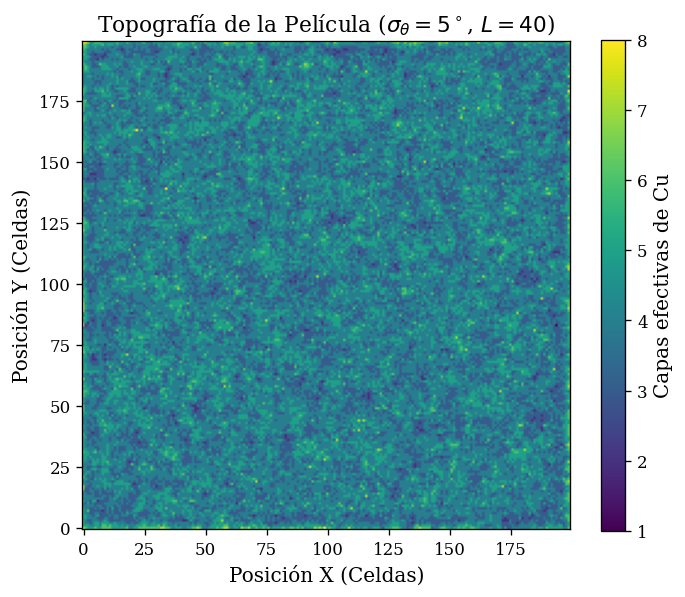

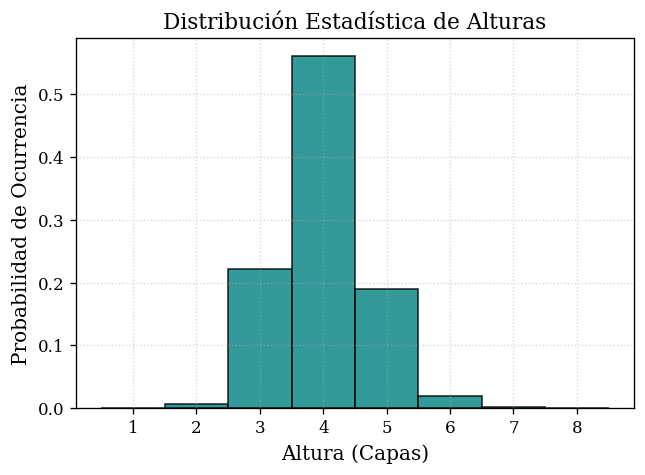

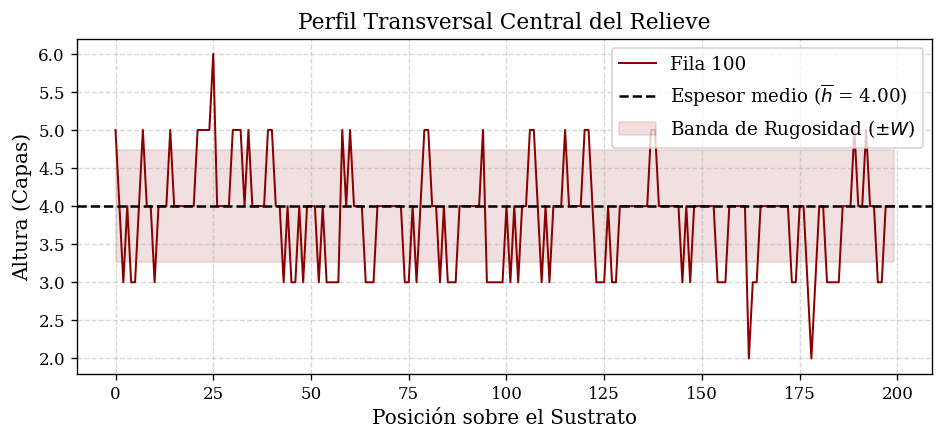

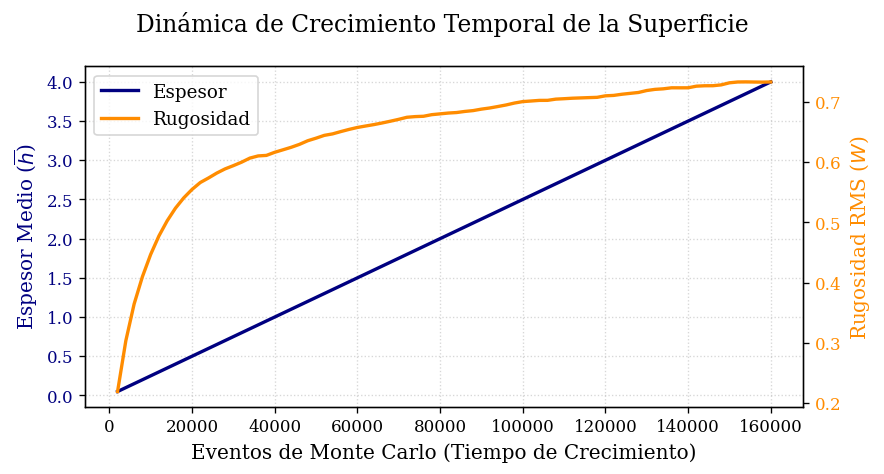

In [5]:
# =============================================================================
# SECCIÓN 6: ANÁLISIS CRONOLÓGICO Y FIRMAS TRADICIONALES EN CONDICIÓN BASE
# =============================================================================

print("Ejecutando simulación diagnóstica para la condición base...")
superficie_base, hist_ev, hist_esp, hist_rug = ejecutar_simulacion_angular_con_historial(
    NX, NY, N_EVENTOS, TEMPERATURE, MAX_DIFFUSION_STEPS, SOURCE_DISTANCE, SIGMA_ANGLE, GUARDAR_CADA
)

# Impresión de Métricas de Control de Consola
print("=" * 65)
print("          MÉTRICAS DE LA PELÍCULA CON INCIDENCIA ANGULAR (BASE)      ")
print("=" * 65)
print(f"Dimensiones del sustrato : {NX} x {NY} celdas")
print(f"Partículas depositadas   : {N_EVENTOS}")
print(f"Altura máxima alcanzada  : {np.max(superficie_base)} capas")
print(f"Altura mínima alcanzada  : {np.min(superficie_base)} capas")
print("-" * 65)
print(f"Espesor medio simulado   : {np.mean(superficie_base):.4f} capas")
print(f"Rugosidad RMS simulada   : {np.std(superficie_base):.4f}")
print("=" * 65)

# --- DESPLIEGUE VISUAL DE LAS 4 FIRMAS TRADICIONALES ---

# 1. Topografía Superficial 2D
plt.figure(figsize=(6, 5))
plt.imshow(superficie_base, origin="lower", cmap="viridis")
plt.colorbar(label="Capas efectivas de Cu")
plt.xlabel("Posición X (Celdas)")
plt.ylabel("Posición Y (Celdas)")
plt.title(rf"Topografía de la Película ($\sigma_\theta = {SIGMA_ANGLE}^\circ$, $L = {SOURCE_DISTANCE}$)")
plt.tight_layout()
plt.savefig("angular_topografia_2d.png", bbox_inches="tight")
plt.show()

# 2. Histograma de Distribución de Alturas
plt.figure(figsize=(6, 4))
bins_base = np.arange(np.min(superficie_base), np.max(superficie_base) + 2) - 0.5
plt.hist(superficie_base.ravel(), bins=bins_base, density=True, color="teal", edgecolor="black", alpha=0.8)
plt.xlabel("Altura (Capas)")
plt.ylabel("Probabilidad de Ocurrencia")
plt.title("Distribución Estadística de Alturas")
plt.grid(True, linestyle=":", alpha=0.5)
plt.savefig("angular_histograma.png", bbox_inches="tight")
plt.show()

# 3. Perfil Transversal Central 1D
fila_central = NX // 2
plt.figure(figsize=(8, 3.8))
plt.plot(superficie_base[fila_central, :], color='darkred', linewidth=1.2, label=f'Fila {fila_central}')
esp_m = np.mean(superficie_base)
rug_m = np.std(superficie_base)
plt.axhline(esp_m, color='black', linestyle='--', label=rf'Espesor medio ($\overline{{h}}$ = {esp_m:.2f})')
plt.fill_between(range(NY), esp_m - rug_m, esp_m + rug_m, color='darkred', alpha=0.12, label=r'Banda de Rugosidad ($\pm W$)')
plt.title('Perfil Transversal Central del Relieve')
plt.xlabel('Posición sobre el Sustrato')
plt.ylabel('Altura (Capas)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig("angular_perfil_unidimensional.png", bbox_inches="tight")
plt.show()

# 4. Evolución Temporal Combinada
fig, ax1 = plt.subplots(figsize=(7.5, 4))
color_esp = 'navy'
ax1.set_xlabel('Eventos de Monte Carlo (Tiempo de Crecimiento)')
ax1.set_ylabel(r'Espesor Medio ($\overline{h}$)', color=color_esp)
ax1.plot(hist_ev, hist_esp, color=color_esp, linewidth=2, label='Espesor')
ax1.tick_params(axis='y', labelcolor=color_esp)
ax1.grid(True, linestyle=':', alpha=0.5)

ax2 = ax1.twinx()  
color_rug = 'darkorange'
ax2.set_ylabel(r'Rugosidad RMS ($W$)', color=color_rug)
ax2.plot(hist_ev, hist_rug, color=color_rug, linewidth=2, label='Rugosidad')
ax2.tick_params(axis='y', labelcolor=color_rug)

fig.suptitle('Dinámica de Crecimiento Temporal de la Superficie')
fig.tight_layout()
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.savefig("angular_evolucion_temporal.png", bbox_inches="tight")
plt.show()

In [6]:
# =============================================================================
# SECCIÓN 7: EXPERIMENTO COMPUTACIONAL I — BARRIDO DE DISPERSIÓN ANGULAR
# =============================================================================

ANGLE_VALUES = [0, 2, 5, 10, 15, 20, 30]
N_REPLICAS = 5
resultados_angulos = []

for sigma in ANGLE_VALUES:
    print(f"Evaluando dispersión angular: sigma = {sigma}°...")
    t_list, r_list, max_list, min_list = [], [], [], []
    
    for _ in range(N_REPLICAS):
        surf = ejecutar_simulacion_angular(NX, NY, N_EVENTOS, TEMPERATURE, MAX_DIFFUSION_STEPS, SOURCE_DISTANCE, sigma)
        t_list.append(np.mean(surf))
        r_list.append(np.std(surf))
        max_list.append(np.max(surf))
        min_list.append(np.min(surf))
        
    resultados_angulos.append({
        "Sigma (°)": sigma,
        "Espesor medio": np.mean(t_list),
        "Desviación espesor": np.std(t_list),
        "Rugosidad media": np.mean(r_list),
        "Desviación rugosidad": np.std(r_list),
        "Altura máxima": np.mean(max_list),
        "Desviación máxima": np.std(max_list),
        "Altura mínima": np.mean(min_list),
        "Desviación mínima": np.std(min_list)
})

df_angulos = pd.DataFrame(resultados_angulos)
df_angulos.round(3)

Evaluando dispersión angular: sigma = 0°...
Evaluando dispersión angular: sigma = 2°...
Evaluando dispersión angular: sigma = 5°...
Evaluando dispersión angular: sigma = 10°...
Evaluando dispersión angular: sigma = 15°...
Evaluando dispersión angular: sigma = 20°...
Evaluando dispersión angular: sigma = 30°...


,Sigma (°),Espesor medio,Desviación espesor,Rugosidad media,Desviación rugosidad,Altura máxima,Desviación máxima,Altura mínima,Desviación mínima
0,0,4.0,0.0,0.705,0.004,8.0,0.632,1.8,0.40
1,2,4.0,0.0,0.704,0.003,8.2,0.400,1.4,0.49
2,5,4.0,0.0,0.731,0.003,9.0,0.000,1.6,0.49
3,10,4.0,0.0,0.878,0.009,13.8,1.327,1.0,0.00
4,15,4.0,0.0,1.130,0.009,26.2,3.370,1.0,0.00
5,20,4.0,0.0,1.501,0.010,46.0,3.225,1.0,0.00
6,30,4.0,0.0,2.804,0.025,121.0,6.633,0.2,0.40


In [7]:
# =============================================================================
# SECCIÓN 8: EXPERIMENTO COMPUTACIONAL II — BARRIDO DE DISTANCIA FUENTE-SUSTRATO
# =============================================================================

DISTANCE_VALUES = [10, 20, 40, 60, 80]
SIGMA_FIJO = 10
resultados_distancias = []

for dist in DISTANCE_VALUES:
    print(f"Evaluando geometría de cámara: L = {dist} unidades...")
    r_list = []
    
    for _ in range(N_REPLICAS):
        surf = ejecutar_simulacion_angular(NX, NY, N_EVENTOS, TEMPERATURE, MAX_DIFFUSION_STEPS, dist, SIGMA_FIJO)
        r_list.append(np.std(surf))
        
    resultados_distancias.append({
        "Distancia": dist,
        "Rugosidad media": np.mean(r_list),
        "Desviación rugosidad": np.std(r_list)
    })

df_distancias = pd.DataFrame(resultados_distancias)
df_distancias.round(3)

Evaluando geometría de cámara: L = 10 unidades...
Evaluando geometría de cámara: L = 20 unidades...
Evaluando geometría de cámara: L = 40 unidades...
Evaluando geometría de cámara: L = 60 unidades...
Evaluando geometría de cámara: L = 80 unidades...


,Distancia,Rugosidad media,Desviación rugosidad
0,10,0.707,0.004
1,20,0.732,0.005
2,40,0.881,0.003
3,60,1.110,0.012
4,80,1.393,0.007


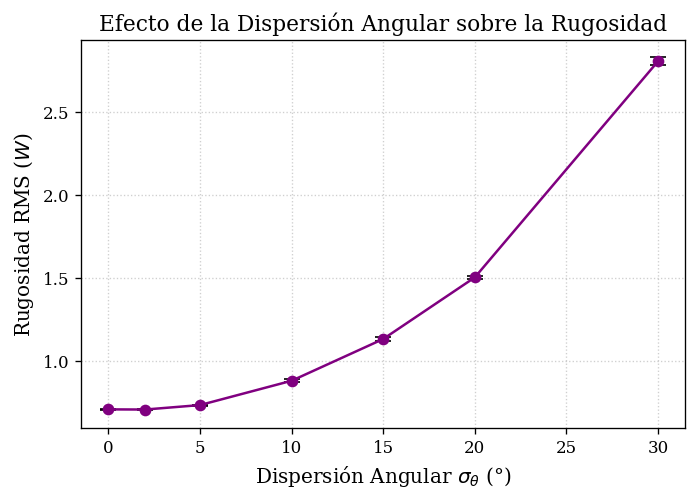

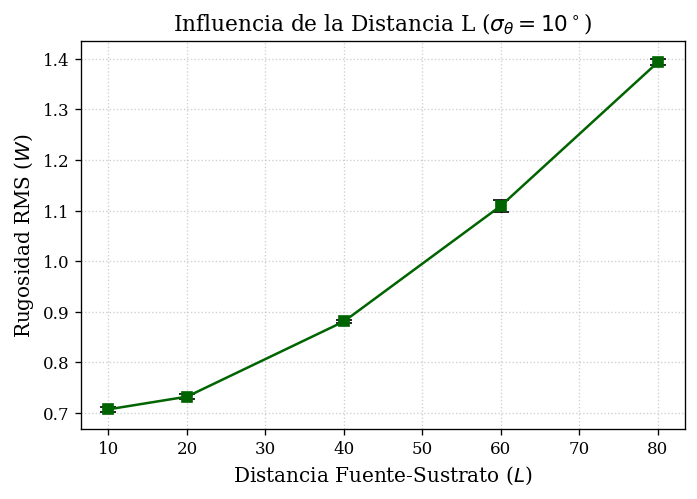

In [8]:
# =============================================================================
# SECCIÓN 9: GENERACIÓN DE CURVAS DE TENDENCIA GEOMÉTRICA
# =============================================================================

# Graficar Rugosidad vs Sigma de Ángulo
plt.figure(figsize=(6.5, 4.2))
plt.errorbar(
    df_angulos["Sigma (°)"],
    df_angulos["Rugosidad media"],
    yerr=df_angulos["Desviación rugosidad"],
    fmt="o-",
    color="purple",
    ecolor="black",
    capsize=5,
    lw=1.5
)
plt.xlabel(r"Dispersión Angular $\sigma_\theta$ (°)")
plt.ylabel(r"Rugosidad RMS ($W$)")
plt.title("Efecto de la Dispersión Angular sobre la Rugosidad")
plt.grid(True, linestyle=":", alpha=0.6)
plt.savefig("grafica_rugosidad_vs_sigma.png", bbox_inches="tight")
plt.show()

# Graficar Rugosidad vs Distancia Fuente-Sustrato
plt.figure(figsize=(6.5, 4.2))
plt.errorbar(
    df_distancias["Distancia"],
    df_distancias["Rugosidad media"],
    yerr=df_distancias["Desviación rugosidad"],
    fmt="s-",
    color="darkgreen",
    ecolor="black",
    capsize=5,
    lw=1.5
)
plt.xlabel(r"Distancia Fuente-Sustrato ($L$)")
plt.ylabel(r"Rugosidad RMS ($W$)")
plt.title(rf"Influencia de la Distancia L ($\sigma_\theta = {SIGMA_FIJO}^\circ$)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.savefig("grafica_rugosidad_vs_distancia.png", bbox_inches="tight")
plt.show()


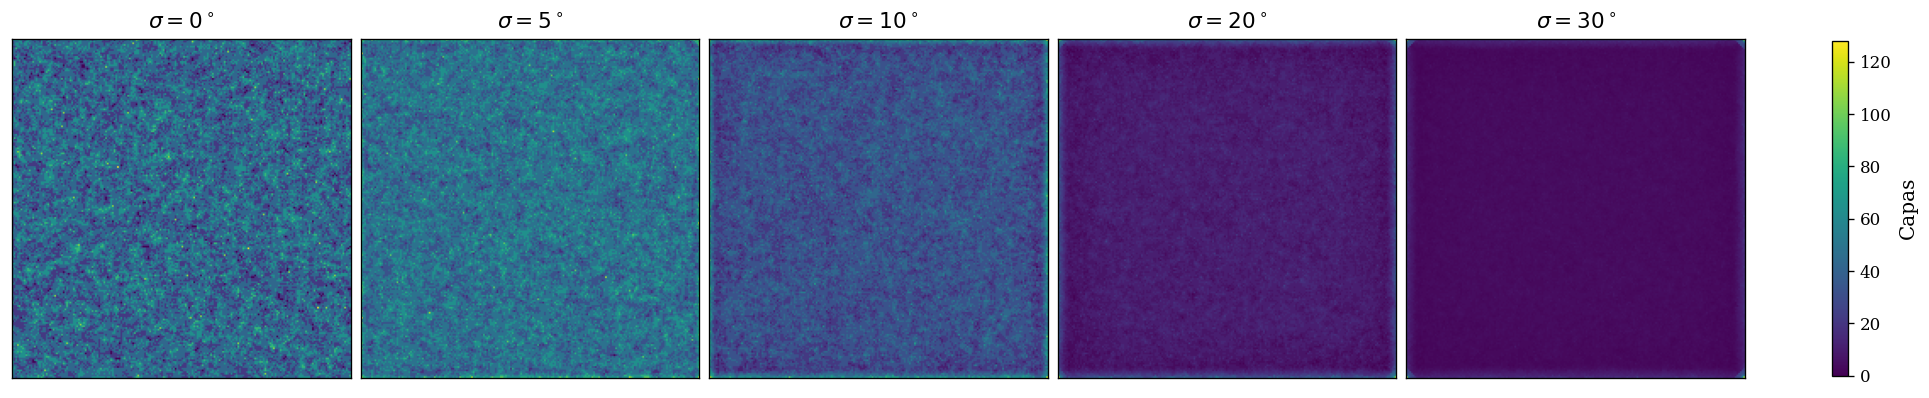

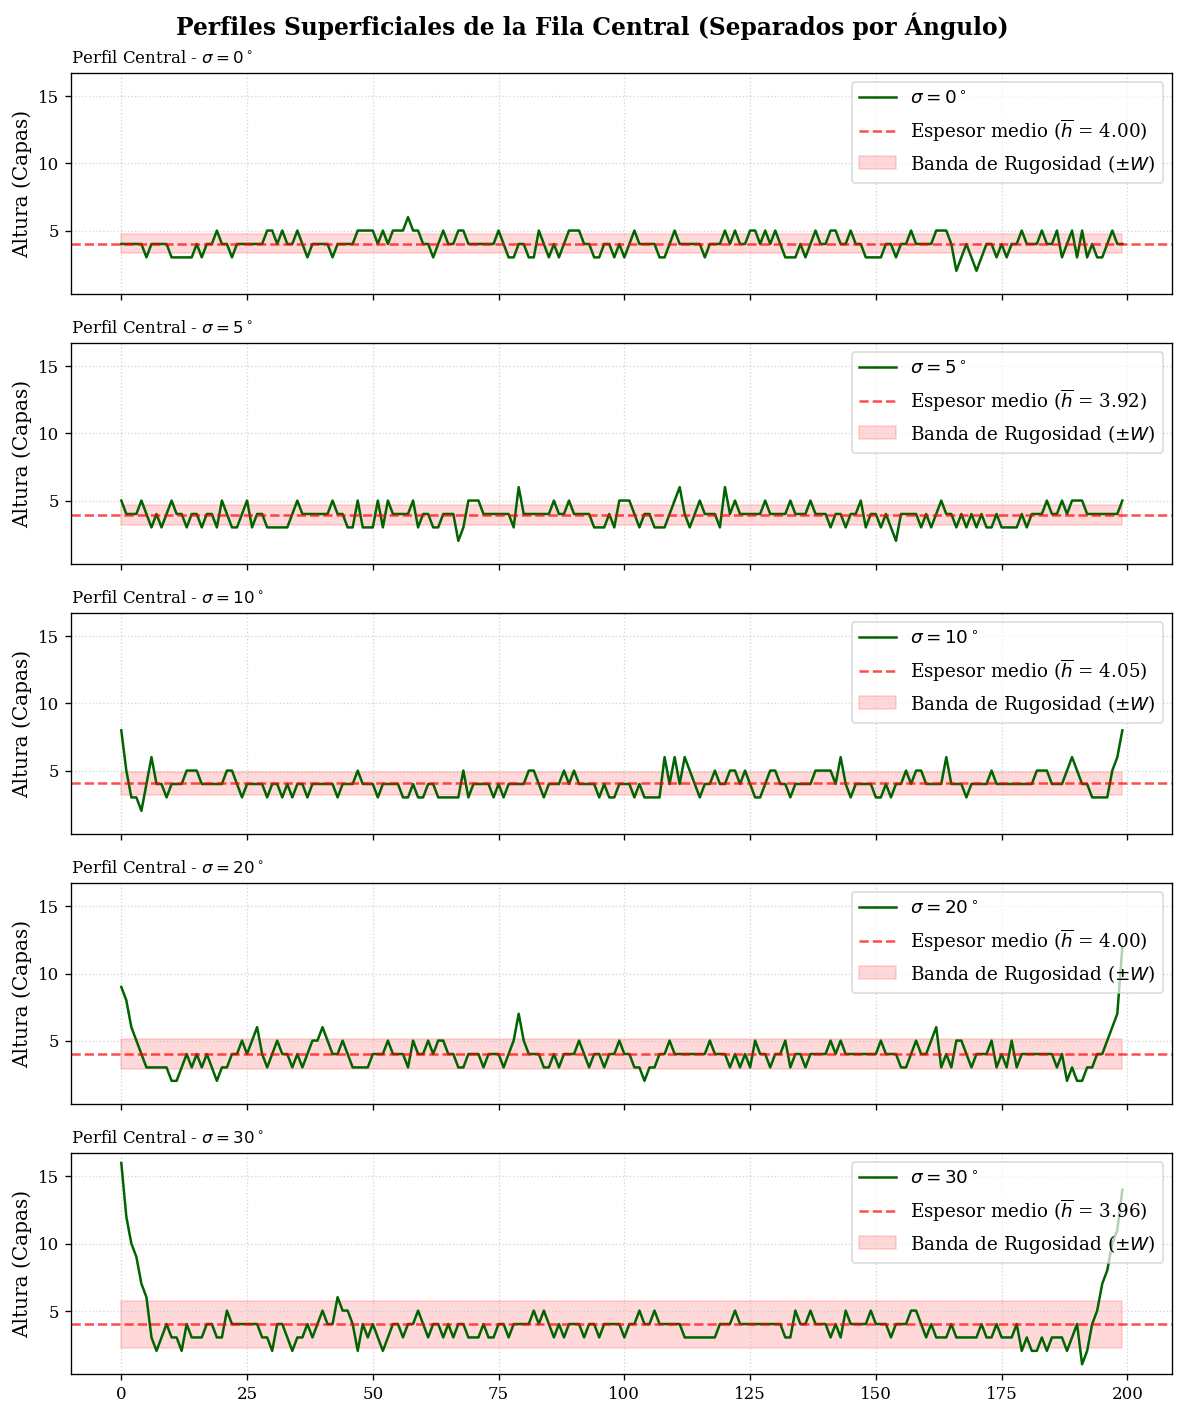

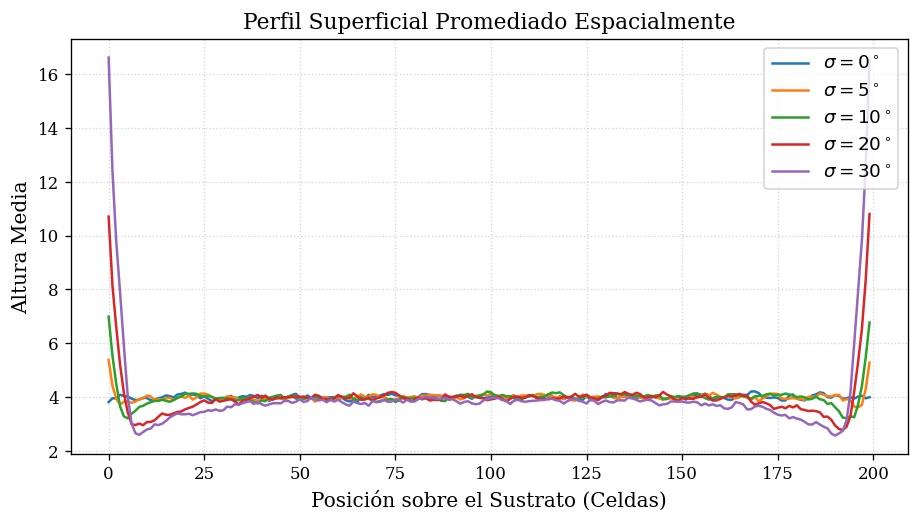

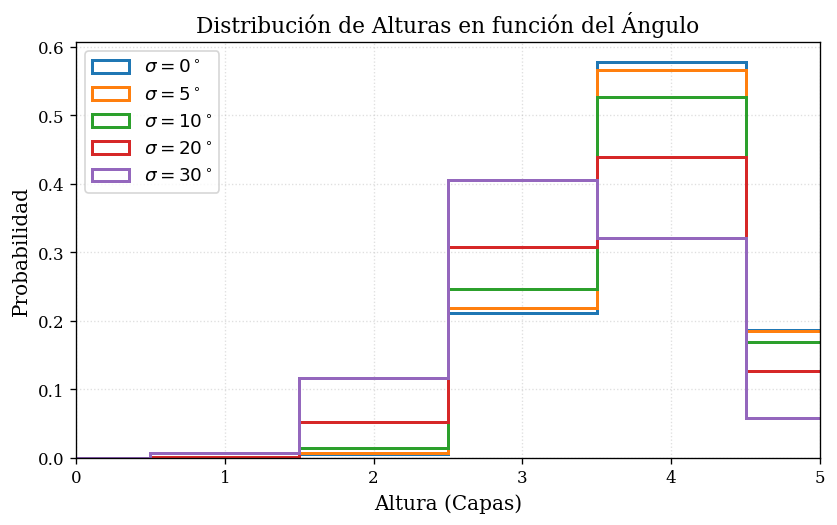

In [9]:
# =============================================================================
# SECCIÓN 10: INSPECCIÓN Y COMPARACIÓN MORFOLÓGICA MULTI-ÁNGULO
# =============================================================================

SIGMAS_A_MOSTRAR = [0, 5, 10, 20, 30]
matrices_comparativas = []
center_row = NX // 2   # fila central del sustrato

# -------------------------------------------------------------------------
# Simulaciones únicas controladas para inspección visual
# -------------------------------------------------------------------------
for s in SIGMAS_A_MOSTRAR:
    mat = ejecutar_simulacion_angular(NX, NY, N_EVENTOS, TEMPERATURE,
                                      MAX_DIFFUSION_STEPS, SOURCE_DISTANCE, s)
    matrices_comparativas.append(mat)

# -------------------------------------------------------------------------
# 1. Mapeo Topográfico Lateral Comparativo
# -------------------------------------------------------------------------
fig, axes = plt.subplots(1, len(SIGMAS_A_MOSTRAR), figsize=(16, 3.8), constrained_layout=True)
for ax, surf, s in zip(axes, matrices_comparativas, SIGMAS_A_MOSTRAR):
    im = ax.imshow(surf, origin="lower", cmap="viridis")
    ax.set_title(rf"$\sigma = {s}^\circ$")
    ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=axes, shrink=0.75, label="Capas")
plt.savefig("comparativa_topografica_angular.png", bbox_inches="tight")
plt.show()

# -------------------------------------------------------------------------
# 2. Perfiles de la Fila Central (separados por ángulo)
# -------------------------------------------------------------------------
fig, axes = plt.subplots(len(SIGMAS_A_MOSTRAR), 1, figsize=(10, 12), sharex=True, sharey=True)

for ax, surf, s in zip(axes, matrices_comparativas, SIGMAS_A_MOSTRAR):
    perfil = surf[center_row, :]
    ax.plot(perfil, lw=1.5, color="darkgreen", label=rf"$\sigma = {s}^\circ$")
    ax.axhline(np.mean(perfil), color="red", linestyle="--", alpha=0.7,
               label=rf"Espesor medio ($\overline{{h}}$ = {np.mean(perfil):.2f})")
    ax.fill_between(range(NX), np.mean(perfil) - np.std(perfil),
                    np.mean(perfil) + np.std(perfil),
                    color="red", alpha=0.15, label=r"Banda de Rugosidad ($\pm W$)")
    ax.set_title(rf"Perfil Central - $\sigma = {s}^\circ$", fontsize=10, loc="left")
    ax.set_ylabel("Altura (Capas)")
    ax.grid(True, linestyle=":", alpha=0.5)
    ax.legend(loc="upper right", framealpha=0.7)

fig.suptitle("Perfiles Superficiales de la Fila Central (Separados por Ángulo)", fontweight="bold")
plt.tight_layout()
plt.savefig("comparativa_perfiles_centrales_subplots.png", bbox_inches="tight")
plt.show()

# -------------------------------------------------------------------------
# 3. Perfiles Promedio sobre el Eje de Simetría
# -------------------------------------------------------------------------
plt.figure(figsize=(9, 4.5))
for surf, s in zip(matrices_comparativas, SIGMAS_A_MOSTRAR):
    perfil_promedio = np.mean(surf, axis=0)
    plt.plot(perfil_promedio, label=rf"$\sigma = {s}^\circ$", lw=1.5)
plt.xlabel("Posición sobre el Sustrato (Celdas)")
plt.ylabel("Altura Media")
plt.title("Perfil Superficial Promediado Espacialmente")
plt.grid(True, linestyle=":", alpha=0.5)
plt.legend(loc="upper right")
plt.savefig("comparativa_perfiles_promedio.png", bbox_inches="tight")
plt.show()

# -------------------------------------------------------------------------
# 4. Superposición de Histogramas de Alturas
# -------------------------------------------------------------------------
plt.figure(figsize=(8, 4.5))
for surf, s in zip(matrices_comparativas, SIGMAS_A_MOSTRAR):
    bins_c = np.arange(surf.min(), surf.max() + 2) - 0.5
    plt.hist(surf.ravel(), bins=bins_c, density=True, histtype="step",
             lw=1.8, label=rf"$\sigma = {s}^\circ$")
plt.xlabel("Altura (Capas)")
plt.ylabel("Probabilidad")
plt.title("Distribución de Alturas en función del Ángulo")
plt.grid(True, linestyle=":", alpha=0.4)
plt.legend()
plt.xlim(0, 5)  # Acercamiento para fases de crecimiento ultradelgado
plt.savefig("comparativa_histogramas_paso.png", bbox_inches="tight")
plt.show()


## 11. Análisis de Resultados

Este cuarto notebook incorpora por primera vez una representación geométrica más realista del proceso de evaporación térmica, sustituyendo la incidencia perfectamente normal por un flujo con dispersión angular proveniente de una fuente situada a una distancia finita del sustrato. Este cambio introduce un desplazamiento lateral de los adátomos durante el vuelo balístico, permitiendo estudiar cómo la geometría de la cámara modifica la morfología final de la película.

### A. Diagnóstico de la Condición Base

La condición de referencia ($\sigma_\theta = 5^\circ$, $L = 40$) se simuló sobre un sustrato de **200 × 200 celdas** utilizando **160 000 eventos de deposición**, obteniéndose las siguientes propiedades:

- Espesor medio: **4.0000 capas**
- Rugosidad RMS: **0.7356**
- Altura mínima: **1 capa**
- Altura máxima: **9 capas**

A diferencia de los notebooks anteriores, el sistema ya no se encuentra en un régimen de nucleación inicial sino en una etapa de crecimiento estable de la película. El mapa topográfico presenta una cobertura prácticamente completa del sustrato, mientras que el histograma de alturas muestra una distribución aproximadamente centrada alrededor de las **4 capas**, con una dispersión moderada producida por las fluctuaciones estadísticas propias del proceso de deposición y por la difusión superficial activada térmicamente.

### B. Influencia de la Dispersión Angular

La Figura correspondiente muestra que la rugosidad RMS aumenta de forma continua al incrementar la dispersión angular del haz incidente.

* Cuando la evaporación ocurre con incidencia casi normal ($\sigma_\theta \approx 0^\circ$), la mayor parte de los átomos impacta muy cerca de la vertical sobre la cual fue emitida, generando una película relativamente uniforme.

* Conforme aumenta la desviación angular, el desplazamiento lateral promedio

$$
\Delta x = L \tan(\theta)
$$

crece progresivamente, distribuyendo los puntos de impacto sobre una región cada vez más amplia del sustrato. Como consecuencia, aumenta la variabilidad local del espesor y aparecen diferencias de altura más pronunciadas entre regiones vecinas, incrementando la rugosidad superficial.

### C. Influencia de la Distancia Fuente-Sustrato

El efecto de la geometría de la cámara también puede analizarse modificando la distancia entre la fuente evaporante y el sustrato.

Los resultados obtenidos fueron:

| Distancia $L$ | Rugosidad RMS |
|---------------|---------------|
|10|0.711|
|20|0.736|
|40|0.876|
|60|1.105|
|80|1.390|

Se observa un incremento prácticamente monótono de la rugosidad conforme aumenta la separación entre fuente y sustrato.

* Este comportamiento es consistente con la relación geométrica

$$
\Delta x = L \tan(\theta),
$$

que indica que un mismo ángulo de emisión genera desplazamientos laterales mayores cuando la distancia de vuelo aumenta. En consecuencia, las partículas llegan distribuidas sobre una región más extensa del sustrato, aumentando las fluctuaciones espaciales del espesor y favoreciendo la aparición de una superficie más rugosa.

### D. Firmas Morfológicas y Perfiles Transversales

La comparación de los mapas topográficos y de los perfiles superficiales permite visualizar claramente cómo la dispersión angular modifica la morfología de la película:

1. **Mapas Topográficos 2D:** Para valores pequeños de $\sigma_\theta$ la superficie presenta una textura relativamente homogénea. Al incrementar la dispersión angular aparecen variaciones locales de altura cada vez más pronunciadas, evidenciando un crecimiento más irregular.

2. **Perfiles Superficiales Promedio:** Los perfiles obtenidos sobre la fila central muestran que, para incidencias cercanas a la normal, las fluctuaciones permanecen confinadas alrededor del espesor medio. En cambio, para $\sigma_\theta = 20^\circ$ y $30^\circ$ las oscilaciones aumentan considerablemente, reflejando el incremento de la rugosidad superficial.

3. **Distribución Estadística de Alturas:** Los histogramas muestran un ensanchamiento progresivo de la distribución conforme aumenta la dispersión angular. Esto indica una mayor probabilidad de encontrar simultáneamente regiones relativamente altas y relativamente bajas, comportamiento consistente con el incremento observado en la rugosidad RMS.

## 12. Conclusiones

La incorporación de una fuente situada a distancia finita introduce un grado adicional de realismo en el modelo de evaporación térmica. Tanto la dispersión angular como la separación fuente-sustrato modifican la distribución espacial de los impactos, produciendo un incremento sistemático de la rugosidad superficial.

Aunque la difusión superficial continúa suavizando parcialmente la película, su efecto deja de ser suficiente para compensar completamente el aumento del desplazamiento lateral cuando la geometría de deposición se vuelve más desfavorable.

En conjunto, este notebook demuestra que parámetros puramente geométricos de la cámara de evaporación pueden influir de manera importante sobre la microestructura final de una película delgada, incluso manteniendo constantes la temperatura, la tasa de deposición y el número total de partículas.


## 13. Referencias

**Fuentes académicas primarias**

* Nieuwenhuizen, J. M., & Haanstra, H. B. (1966). Microfractography of thin films. *Philips Technical Review, 27*, 87–91.

**Recursos complementarios**

* Barabási, A.-L., & Stanley, H. E. (1995). *Fractal concepts in surface growth*. Cambridge University Press.
